# Question 1 

In [6]:
import numpy as np
from q1 import simulate_lognormal_sum, wasserstein_1d, reject_abc


In [ ]:
seed_value = 42
main_rng = np.random.default_rng(seed_value)
    
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200  
    
print("Generating strictly defined observational data...")
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=main_rng)

##### epsilon and the prior affect the result ###
    
epsilon_val = 0.5 
    
prior_configs = [
        {"s": 1.0, "t": 1.0, "name": "Well-calibrated"},
        {"s": 10.0, "t": 10.0, "name": "Highly diffuse (Efficiency drop)"},
        {"s": 0.01, "t": 0.01, "name": "Highly concentrated (Prior bias risk)"}
    ]
    
print(f"\n--- Rejection-ABC Empirical Results (Target: mu={mu_true}, sigma={sigma_true}) ---")
for config in prior_configs:
    print(f"\nEvaluating '{config['name']}' prior specification (s={config['s']}, t={config['t']}):")
        
        # Pass the isolated generator down the execution pipeline
    samples, acc_rate = reject_abc(
        Y_obs, L_true, config['s'], config['t'], epsilon_val, num_samples=50, rng=main_rng
        )
        
    print(f"  -> Acceptance Rate : {acc_rate:.4%}")
        
    if len(samples) > 0:
        mu_est = np.mean(samples[:, 0])
        sigma_est = np.mean(samples[:, 1])
        print(f"  -> Estimated mu    : {mu_est:.4f}")
        print(f"  -> Estimated sigma : {sigma_est:.4f}")
    else:
        print("  -> Estimated mu    : N/A (0 samples accepted)")
        print("  -> Estimated sigma : N/A (0 samples accepted)")

    [!] Computational limit reached (200000 iterations). Only 445 samples accepted.
    [!] Computational limit reached (200000 iterations). Only 56 samples accepted.
    [!] Computational limit reached (200000 iterations). Only 0 samples accepted.
Saved: fig1_prior_impact.png
    [!] Computational limit reached (500000 iterations). Only 29 samples accepted.
ε=0.10  acc=0.0058%  μ̂=-0.0042  σ̂=0.3024
    [!] Computational limit reached (500000 iterations). Only 352 samples accepted.
ε=0.30  acc=0.0704%  μ̂=-0.0140  σ̂=0.3320
ε=0.50  acc=0.2165%  μ̂=-0.0291  σ̂=0.3726
ε=1.00  acc=1.1212%  μ̂=-0.0756  σ̂=0.4703
ε=2.00  acc=5.1300%  μ̂=-0.1787  σ̂=0.6213
Saved: fig2_epsilon_impact.png


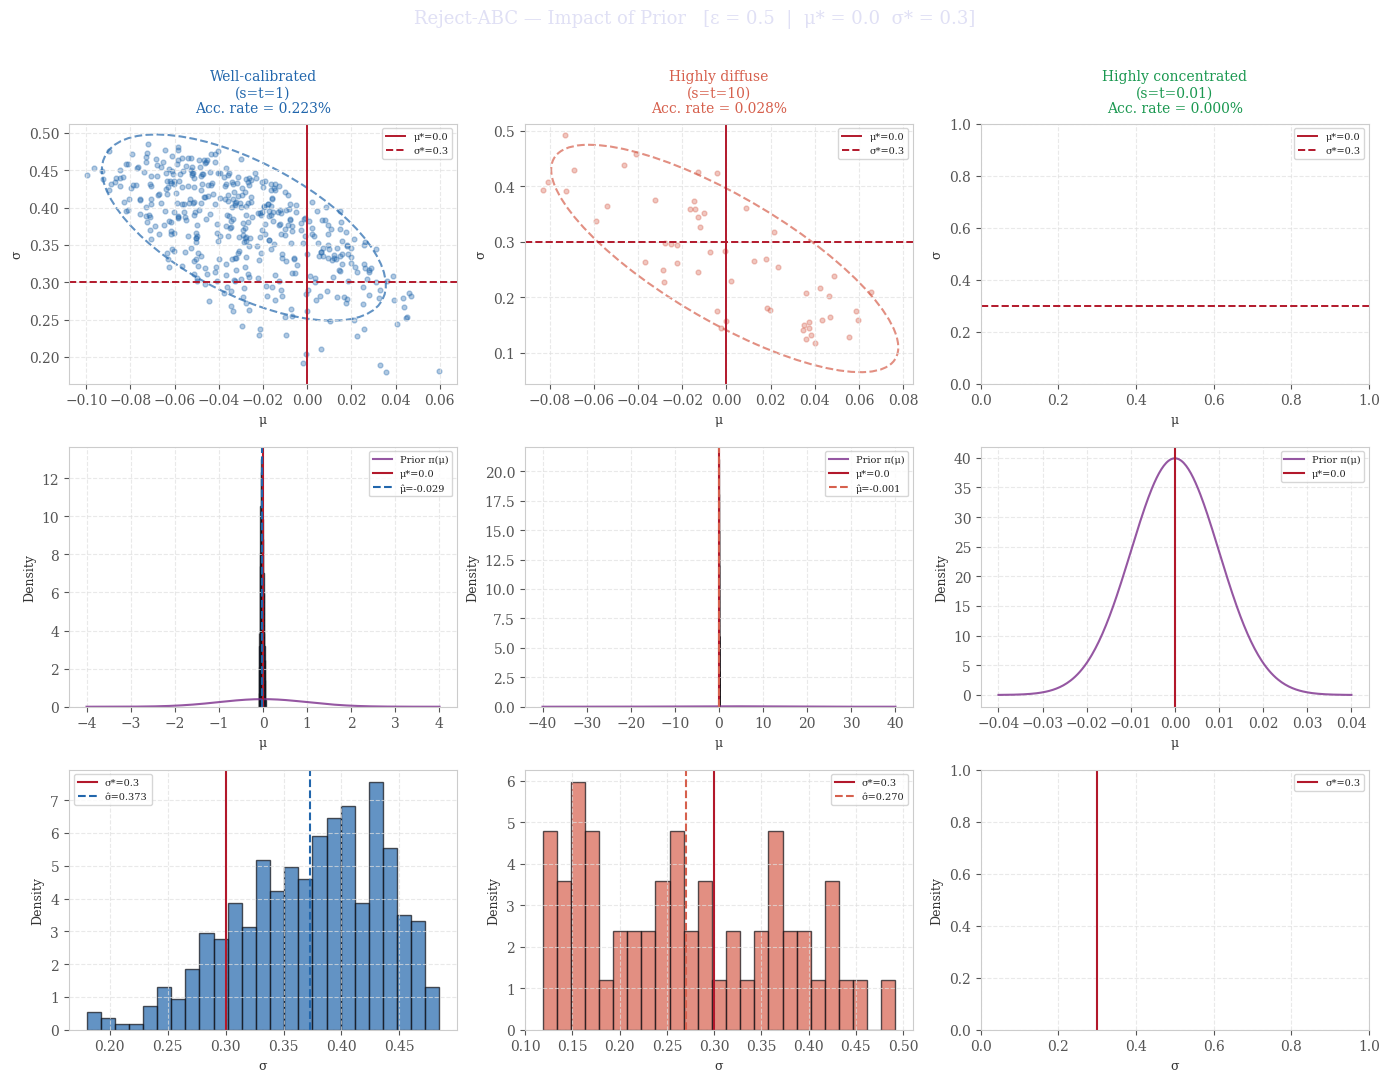

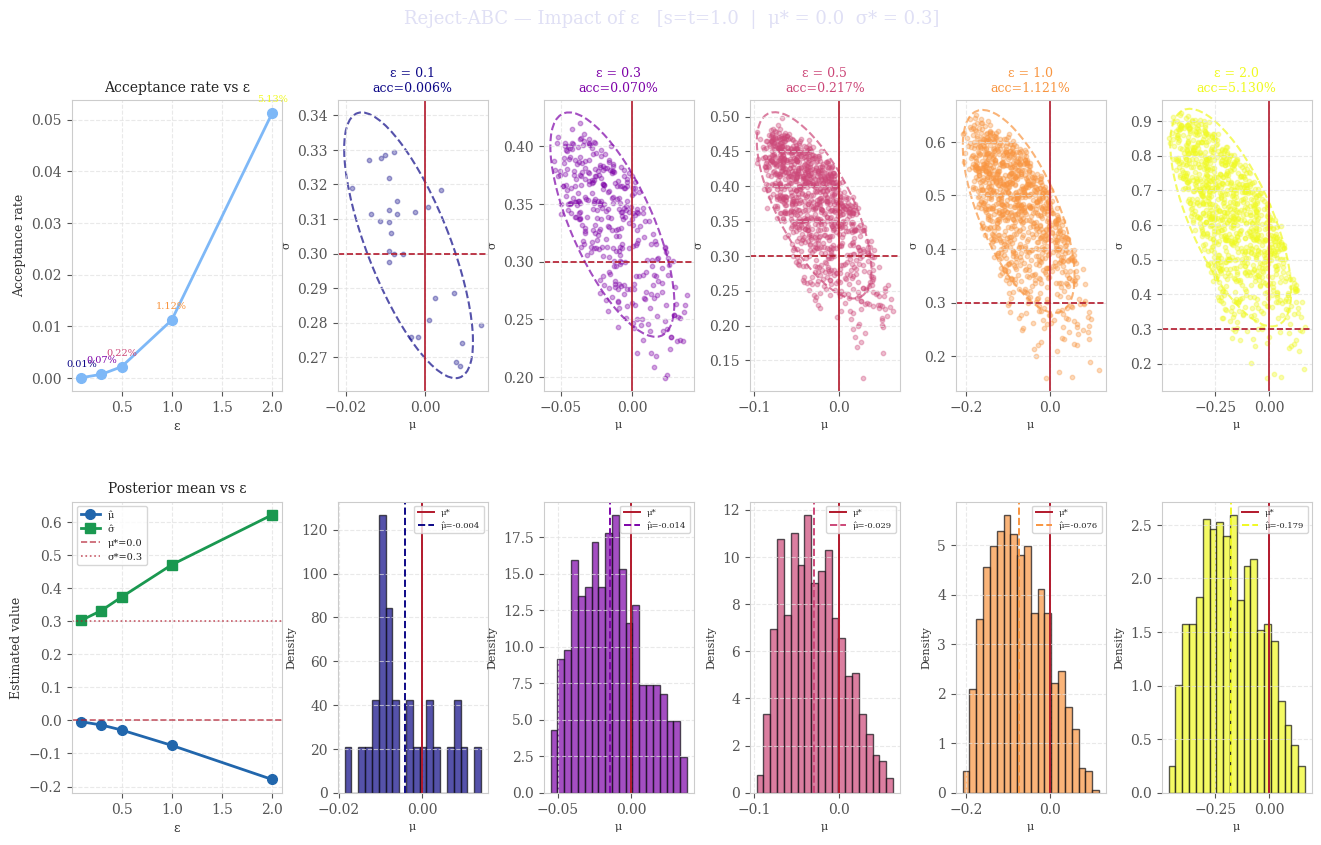

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from q1 import simulate_lognormal_sum, wasserstein_1d, reject_abc

# ─────────────────────────────────────────────
#  GLOBAL SEED & TRUE PARAMETERS
# ─────────────────────────────────────────────


    
SEED      = 42
L_TRUE    = 10
MU_TRUE   = 0.0
SIGMA_TRUE = 0.3
N_OBS     = 1000
N_SAMPLES = 1000   # accepted samples per run (increase for smoother plots)

main_rng = np.random.default_rng(SEED)
Y_obs = simulate_lognormal_sum(N_OBS, L_TRUE, MU_TRUE, SIGMA_TRUE, rng=main_rng)

# ─────────────────────────────────────────────
#  STYLE
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#cccccc",
    "axes.labelcolor":  "#333333",
    "xtick.color":      "#555555",
    "ytick.color":      "#555555",
    "text.color":       "#222222",
    "grid.color":       "#e0e0e0",
    "grid.linestyle":   "--",
    "grid.alpha":       0.7,
    "font.family":      "serif",
    "axes.titlesize":   10,
    "axes.labelsize":   9,
})

ACCENT    = ["#2166ac", "#d6604d", "#1a9850"]   # bleu / rouge / vert
TRUE_CLR  = "#b2182b"
PRIOR_CLR = "#7b2d8b"

# ─────────────────────────────────────────────
#  HELPER : confidence ellipse (1-sigma)
# ─────────────────────────────────────────────
def plot_ellipse(ax, samples, color, n_std=2.0):
    if len(samples) < 3:
        return
    cov = np.cov(samples[:, 0], samples[:, 1])
    mean = samples.mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(mean, width=w, height=h, angle=angle,
                  edgecolor=color, facecolor="none", lw=1.5, linestyle="--", alpha=0.7)
    ax.add_patch(ell)


# ═══════════════════════════════════════════════════════════════
#  FIGURE 1 — Impact of prior (s, t)   [epsilon fixed]
# ═══════════════════════════════════════════════════════════════
EPSILON_FIXED = 0.5
PRIOR_CONFIGS = [
    {"s": 1.0,  "t": 1.0,  "name": "Well-calibrated\n(s=t=1)"},
    {"s": 10.0, "t": 10.0, "name": "Highly diffuse\n(s=t=10)"},
    {"s": 0.01, "t": 0.01, "name": "Highly concentrated\n(s=t=0.01)"},
]

fig1, axes1 = plt.subplots(3, 3, figsize=(14, 11))
fig1.suptitle(
    f"Reject-ABC — Impact of Prior   [ε = {EPSILON_FIXED}  |  μ* = {MU_TRUE}  σ* = {SIGMA_TRUE}]",
    fontsize=13, color="#e0e0f5", y=0.98
)

for col, cfg in enumerate(PRIOR_CONFIGS):
    rng = np.random.default_rng(SEED + col)          # isolated seed per config
    samples, acc_rate = reject_abc(
        Y_obs, L_TRUE, cfg["s"], cfg["t"],
        EPSILON_FIXED, num_samples=N_SAMPLES,
        max_attempts=200_000, rng=rng
    )

    color = ACCENT[col]
    ax_sc  = axes1[0, col]
    ax_mu  = axes1[1, col]
    ax_sig = axes1[2, col]

    # ── column title ──
    ax_sc.set_title(
        f"{cfg['name']}\nAcc. rate = {acc_rate:.3%}",
        color=color, pad=8
    )

    # ── ROW 0 : scatter (mu, sigma) ──
    if len(samples) > 0:
        ax_sc.scatter(samples[:, 0], samples[:, 1],
                      alpha=0.35, s=12, color=color, rasterized=True)
        plot_ellipse(ax_sc, samples, color)
    ax_sc.axvline(MU_TRUE,    color=TRUE_CLR, lw=1.4, linestyle="-",  label=f"μ*={MU_TRUE}")
    ax_sc.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.4, linestyle="--", label=f"σ*={SIGMA_TRUE}")
    ax_sc.set_xlabel("μ")
    ax_sc.set_ylabel("σ")
    ax_sc.legend(fontsize=7, loc="upper right")
    ax_sc.grid(True)

    # ── ROW 1 : histogram of mu ──
    if len(samples) > 0:
        ax_mu.hist(samples[:, 0], bins=25, density=True,
                   color=color, alpha=0.7, edgecolor="#0f0f14")
    # overlay prior
    x_range = np.linspace(-4 * cfg["s"], 4 * cfg["s"], 300)
    prior_pdf = (1 / (cfg["s"] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x_range / cfg["s"]) ** 2)
    ax_mu.plot(x_range, prior_pdf, color=PRIOR_CLR, lw=1.5, alpha=0.8, label="Prior π(μ)")
    ax_mu.axvline(MU_TRUE, color=TRUE_CLR, lw=1.5, label=f"μ*={MU_TRUE}")
    if len(samples) > 0:
        ax_mu.axvline(samples[:, 0].mean(), color=color, lw=1.5,
                      linestyle="--", label=f"μ̂={samples[:,0].mean():.3f}")
    ax_mu.set_xlabel("μ")
    ax_mu.set_ylabel("Density")
    ax_mu.legend(fontsize=7)
    ax_mu.grid(True)

    # ── ROW 2 : histogram of sigma ──
    if len(samples) > 0:
        ax_sig.hist(samples[:, 1], bins=25, density=True,
                    color=color, alpha=0.7, edgecolor="#0f0f14")
    ax_sig.axvline(SIGMA_TRUE, color=TRUE_CLR, lw=1.5, label=f"σ*={SIGMA_TRUE}")
    if len(samples) > 0:
        ax_sig.axvline(samples[:, 1].mean(), color=color, lw=1.5,
                       linestyle="--", label=f"σ̂={samples[:,1].mean():.3f}")
    ax_sig.set_xlabel("σ")
    ax_sig.set_ylabel("Density")
    ax_sig.legend(fontsize=7)
    ax_sig.grid(True)

fig1.tight_layout(rect=[0, 0, 1, 0.97])
fig1.savefig("fig1_prior_impact.png", dpi=150, bbox_inches="tight", facecolor="white")
print("Saved: fig1_prior_impact.png")


# ═══════════════════════════════════════════════════════════════
#  FIGURE 2 — Impact of epsilon   [prior fixed: s=t=1]
# ═══════════════════════════════════════════════════════════════
S_FIXED = 1.0
T_FIXED = 1.0
EPSILONS = [0.1, 0.3, 0.5, 1.0, 2.0]

results_eps = []
for eps in EPSILONS:
    rng = np.random.default_rng(SEED + 100)
    samp, rate = reject_abc(
        Y_obs, L_TRUE, S_FIXED, T_FIXED,
        eps, num_samples=N_SAMPLES,
        max_attempts=500_000, rng=rng
    )
    results_eps.append({
        "eps":      eps,
        "samples":  samp,
        "rate":     rate,
        "mu_hat":   samp[:, 0].mean() if len(samp) > 0 else np.nan,
        "sigma_hat": samp[:, 1].mean() if len(samp) > 0 else np.nan,
    })
    print(f"ε={eps:.2f}  acc={rate:.4%}  μ̂={results_eps[-1]['mu_hat']:.4f}  σ̂={results_eps[-1]['sigma_hat']:.4f}")

n_eps = len(EPSILONS)
cmap  = plt.cm.plasma
eps_colors = [cmap(i / (n_eps - 1)) for i in range(n_eps)]

fig2 = plt.figure(figsize=(16, 9))
fig2.suptitle(
    f"Reject-ABC — Impact of ε   [s=t={S_FIXED}  |  μ* = {MU_TRUE}  σ* = {SIGMA_TRUE}]",
    fontsize=13, color="#e0e0f5"
)

gs = fig2.add_gridspec(2, n_eps + 1, hspace=0.38, wspace=0.35,
                        width_ratios=[1.4] + [1] * n_eps)

# ── left column: 3 summary curves (acceptance rate, mu_hat, sigma_hat) ──
ax_rate  = fig2.add_subplot(gs[0, 0])
ax_est   = fig2.add_subplot(gs[1, 0])

eps_vals  = [r["eps"]      for r in results_eps]
rates     = [r["rate"]     for r in results_eps]
mu_hats   = [r["mu_hat"]   for r in results_eps]
sig_hats  = [r["sigma_hat"] for r in results_eps]

# acceptance rate
ax_rate.plot(eps_vals, rates, "o-", color="#7eb8f7", lw=2, ms=7)
for i, (e, r) in enumerate(zip(eps_vals, rates)):
    ax_rate.annotate(f"{r:.2%}", (e, r), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=7, color=eps_colors[i])
ax_rate.set_title("Acceptance rate vs ε")
ax_rate.set_xlabel("ε")
ax_rate.set_ylabel("Acceptance rate")
ax_rate.grid(True)

# mu_hat and sigma_hat
ax_est.plot(eps_vals, mu_hats,   "o-", color=ACCENT[0], lw=2, ms=7, label="μ̂")
ax_est.plot(eps_vals, sig_hats,  "s-", color=ACCENT[2], lw=2, ms=7, label="σ̂")
ax_est.axhline(MU_TRUE,    color=TRUE_CLR, lw=1.2, linestyle="--", alpha=0.7, label=f"μ*={MU_TRUE}")
ax_est.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.2, linestyle=":",  alpha=0.7, label=f"σ*={SIGMA_TRUE}")
ax_est.set_title("Posterior mean vs ε")
ax_est.set_xlabel("ε")
ax_est.set_ylabel("Estimated value")
ax_est.legend(fontsize=7)
ax_est.grid(True)

# ── right columns: one scatter per epsilon ──
for i, res in enumerate(results_eps):
    ax_sc = fig2.add_subplot(gs[0, i + 1])   # top row
    ax_h  = fig2.add_subplot(gs[1, i + 1])   # bottom row

    color = eps_colors[i]
    samp  = res["samples"]

    # scatter
    if len(samp) > 0:
        ax_sc.scatter(samp[:, 0], samp[:, 1],
                      alpha=0.35, s=10, color=color, rasterized=True)
        plot_ellipse(ax_sc, samp, color)
    ax_sc.axvline(MU_TRUE,    color=TRUE_CLR, lw=1.2, linestyle="-")
    ax_sc.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.2, linestyle="--")
    ax_sc.set_title(f"ε = {res['eps']}\nacc={res['rate']:.3%}", color=color, fontsize=9)
    ax_sc.set_xlabel("μ", fontsize=8)
    ax_sc.set_ylabel("σ", fontsize=8)
    ax_sc.grid(True)

    # histogram of mu only (bottom row, to keep it readable)
    if len(samp) > 0:
        ax_h.hist(samp[:, 0], bins=20, density=True,
                  color=color, alpha=0.7, edgecolor="#0f0f14")
    ax_h.axvline(MU_TRUE, color=TRUE_CLR, lw=1.4, label=f"μ*")
    if len(samp) > 0:
        ax_h.axvline(samp[:, 0].mean(), color=color, lw=1.4,
                     linestyle="--", label=f"μ̂={samp[:,0].mean():.3f}")
    ax_h.set_xlabel("μ", fontsize=8)
    ax_h.set_ylabel("Density", fontsize=8)
    ax_h.legend(fontsize=6)
    ax_h.grid(True)

fig2.savefig("fig2_epsilon_impact.png", dpi=150, bbox_inches="tight", facecolor="white")
print("Saved: fig2_epsilon_impact.png")

plt.show()


In [1]:
from ABCMCMC import ABCMCMC

# Question 2 

In [1]:
import numpy as np
from q1 import simulate_lognormal_sum, wasserstein_1d
from ABCMCMC import ABCMCMC

L_true, mu_true, sigma_true, n_obs = 10, 0.0, 0.3, 200
epsilon_val    = 0.18
step_mu        = 0.02
step_log_sigma = 0.1
num_samples    = 50000

prior_configs = [
    {"s": 1.0,  "t": 1.0,  "name": "Well-calibrated"},
    {"s": 10.0, "t": 10.0, "name": "Highly diffuse"},
]

rng_data = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}")

for i, config in enumerate(prior_configs):
    rng = np.random.default_rng(100 + i)   # seed isolé par config
    print(f"\n--- {config['name']} (s={config['s']}, t={config['t']}) ---")

    samples, acc_rate = ABCMCMC(
        Y_obs, L_true, config['s'], config['t'],
        epsilon_val, step_mu, step_log_sigma,
        num_samples=num_samples, rng=rng
    )

    print(f"Acceptance Rate : {acc_rate:.4%}")
    print(f"mu estimé       : {np.mean(samples[:, 0]):.4f}  (vrai={mu_true})")
    print(f"log_sigma² est. : {np.mean(samples[:, 1]):.4f}  (vrai={2*np.log(sigma_true):.4f})")

Y_obs mean: 10.2882

--- Well-calibrated (a=2.0, b=1.0, kappa=1.0) ---


TypeError: ABCMCMC() got multiple values for argument 'num_samples'

Taux d'acceptation : 31.04%

────────────────────────────────────────────────────────────
Paramètre        Moyenne      Std  IC 95% bas  IC 95% haut    ESS
────────────────────────────────────────────────────────────
mu               -0.0205   0.0150     -0.0498       0.0084    448  (vrai = 0.000)
log_sigma2       -2.3205   0.2261     -2.7943      -1.8922    266  (vrai = -2.408)
────────────────────────────────────────────────────────────



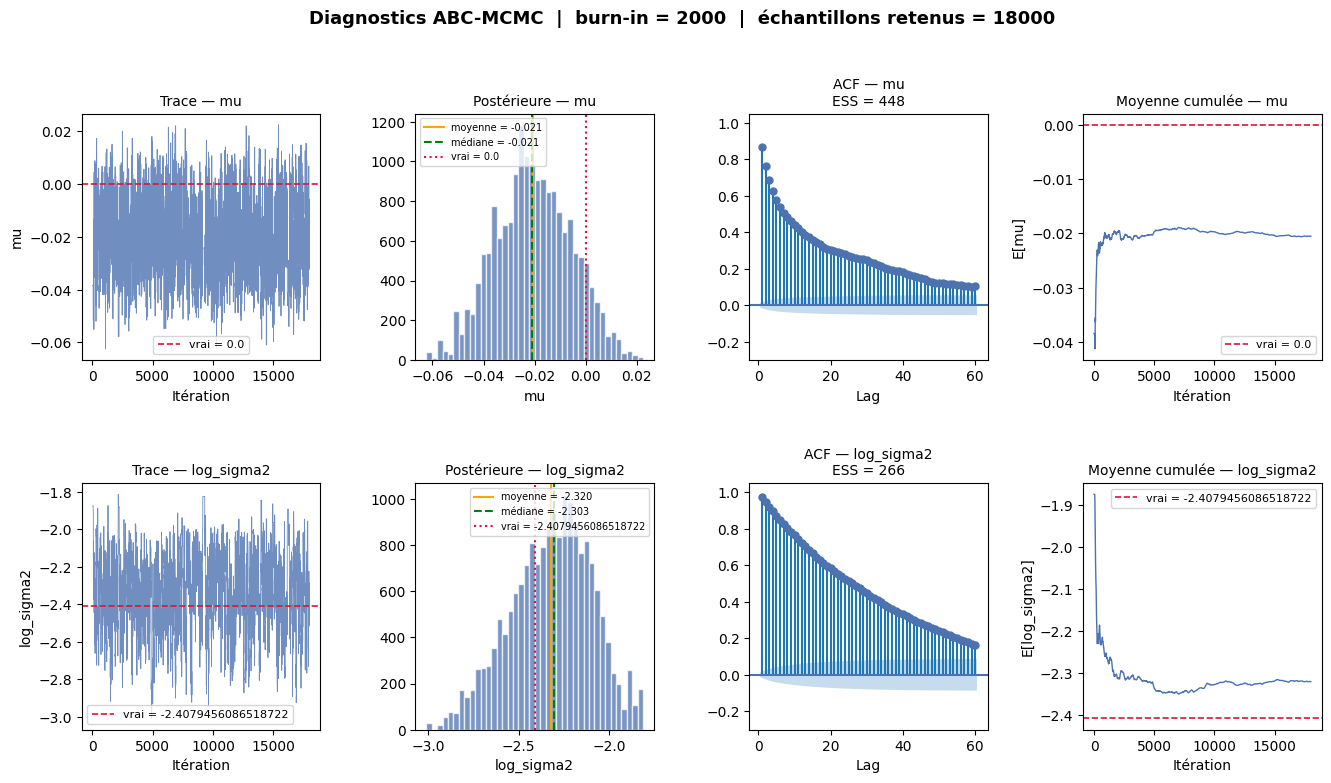

Figure sauvegardée.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


def effective_sample_size(chain_1d):
    """
    ESS = N / (1 + 2 * sum(autocorrelations))
    On tronque la somme quand l'ACF devient négative (méthode de Geyer).
    """
    n = len(chain_1d)
    acf_vals = acf(chain_1d, nlags=min(500, n // 2), fft=True)
    # Méthode de Geyer : on arrête à la première ACF négative
    cutoff = next((i for i, v in enumerate(acf_vals) if v < 0), len(acf_vals))
    ess = n / (1 + 2 * np.sum(acf_vals[1:cutoff]))
    return max(1.0, ess)


def plot_diagnostics(chain, param_names=None, burnin=0, true_values=None):
    """
    Diagnostics complets pour une chaîne ABC-MCMC.

    Paramètres
    ----------
    chain        : np.ndarray (num_samples, n_params)
    param_names  : liste de noms (ex. ['mu', 'log_sigma2'])
    burnin       : nombre d'itérations à ignorer
    true_values  : valeurs vraies (optionnel, pour référence visuelle)
    """
    if param_names is None:
        param_names = [f"theta_{i}" for i in range(chain.shape[1])]

    chain_post = chain[burnin:]
    n_params = chain.shape[1]

    fig = plt.figure(figsize=(16, 4 * n_params))
    gs = gridspec.GridSpec(n_params, 4, figure=fig, hspace=0.5, wspace=0.4)

    for p in range(n_params):
        x = chain_post[:, p]
        name = param_names[p]
        tv = true_values[p] if true_values is not None else None
        ess = effective_sample_size(x)

        # ── 1. Trace plot ──────────────────────────────────────────────────
        ax_trace = fig.add_subplot(gs[p, 0])
        ax_trace.plot(x, lw=0.6, alpha=0.8, color="#4C72B0")
        if tv is not None:
            ax_trace.axhline(tv, color="crimson", lw=1.2, ls="--", label=f"vrai = {tv}")
            ax_trace.legend(fontsize=8)
        ax_trace.set_title(f"Trace — {name}", fontsize=10)
        ax_trace.set_xlabel("Itération")
        ax_trace.set_ylabel(name)

        # ── 2. Histogramme de la postérieure ──────────────────────────────
        ax_hist = fig.add_subplot(gs[p, 1])
        ax_hist.hist(x, bins=40, color="#4C72B0", alpha=0.75, edgecolor="white", lw=0.3)
        ax_hist.axvline(np.mean(x), color="orange", lw=1.5, ls="-",  label=f"moyenne = {np.mean(x):.3f}")
        ax_hist.axvline(np.median(x), color="green",  lw=1.5, ls="--", label=f"médiane = {np.median(x):.3f}")
        if tv is not None:
            ax_hist.axvline(tv, color="crimson", lw=1.5, ls=":", label=f"vrai = {tv}")
        ax_hist.set_title(f"Postérieure — {name}", fontsize=10)
        ax_hist.set_xlabel(name)
        ax_hist.legend(fontsize=7)

        # ── 3. Autocorrélation ────────────────────────────────────────────
        ax_acf = fig.add_subplot(gs[p, 2])
        plot_acf(x, ax=ax_acf, lags=60, alpha=0.05, color="#4C72B0", zero=False)
        ax_acf.set_title(f"ACF — {name}\nESS = {ess:.0f}", fontsize=10)
        ax_acf.set_xlabel("Lag")
        ax_acf.set_ylim(-0.3, 1.05)

        # ── 4. Running mean (convergence) ─────────────────────────────────
        ax_run = fig.add_subplot(gs[p, 3])
        running_mean = np.cumsum(x) / np.arange(1, len(x) + 1)
        ax_run.plot(running_mean, lw=1, color="#4C72B0")
        if tv is not None:
            ax_run.axhline(tv, color="crimson", lw=1.2, ls="--", label=f"vrai = {tv}")
            ax_run.legend(fontsize=8)
        ax_run.set_title(f"Moyenne cumulée — {name}", fontsize=10)
        ax_run.set_xlabel("Itération")
        ax_run.set_ylabel(f"E[{name}]")

    fig.suptitle(
        f"Diagnostics ABC-MCMC  |  burn-in = {burnin}  |  échantillons retenus = {len(chain_post)}",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.savefig("diagnostics_abcmcmc.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée.")


# ── Rapport console ────────────────────────────────────────────────────────────

def print_summary(chain, param_names=None, burnin=0, true_values=None):
    """Affiche ESS, moyenne, écart-type, IC 95% pour chaque paramètre."""
    if param_names is None:
        param_names = [f"theta_{i}" for i in range(chain.shape[1])]
    chain_post = chain[burnin:]

    print(f"\n{'─'*60}")
    print(f"{'Paramètre':<15} {'Moyenne':>8} {'Std':>8} {'IC 95% bas':>11} {'IC 95% haut':>12} {'ESS':>6}")
    print(f"{'─'*60}")
    for p, name in enumerate(param_names):
        x = chain_post[:, p]
        ess = effective_sample_size(x)
        lo, hi = np.percentile(x, [2.5, 97.5])
        tv_str = f"  (vrai = {true_values[p]:.3f})" if true_values is not None else ""
        print(f"{name:<15} {np.mean(x):>8.4f} {np.std(x):>8.4f} {lo:>11.4f} {hi:>12.4f} {ess:>6.0f}{tv_str}")
    print(f"{'─'*60}\n")


# ── Exemple d'utilisation ──────────────────────────────────────────────────────
from ABCMCMC import ABCMCMC
chain, acc_rate = ABCMCMC(
        Y_obs, L_true, 1, 1, epsilon_val,step_mu,step_log_sigma, num_samples=20000, rng=main_rng
        )

print(f"Taux d'acceptation : {acc_rate:.2%}")
print_summary(chain, param_names=["mu", "log_sigma2"], burnin=2000,
              true_values=[0.0, np.log(0.3**2)])
plot_diagnostics(chain, param_names=["mu", "log_sigma2"], burnin=2000,
true_values=[0.0, np.log(0.3**2)])

Lancement de l'évaluation de l'erreur Monte Carlo sur 30 exécutions...
    [!] Computational limit reached (10000 iterations). Only 26 samples accepted.
    [!] Computational limit reached (10000 iterations). Only 21 samples accepted.
    [!] Computational limit reached (10000 iterations). Only 19 samples accepted.
    [!] Computational limit reached (10000 iterations). Only 21 samples accepted.
    [!] Computational limit reached (10000 iterations). Only 20 samples accepted.
  -> Exécution 5/30 terminée.
    [!] Computational limit reached (10000 iterations). Only 22 samples accepted.
    [!] Computational limit reached (10000 iterations). Only 30 samples accepted.
    [!] Computational limit reached (10000 iterations). Only 16 samples accepted.
    [!] Computational limit reached (10000 iterations). Only 34 samples accepted.
    [!] Computational limit reached (10000 iterations). Only 25 samples accepted.
  -> Exécution 10/30 terminée.
    [!] Computational limit reached (10000 itera

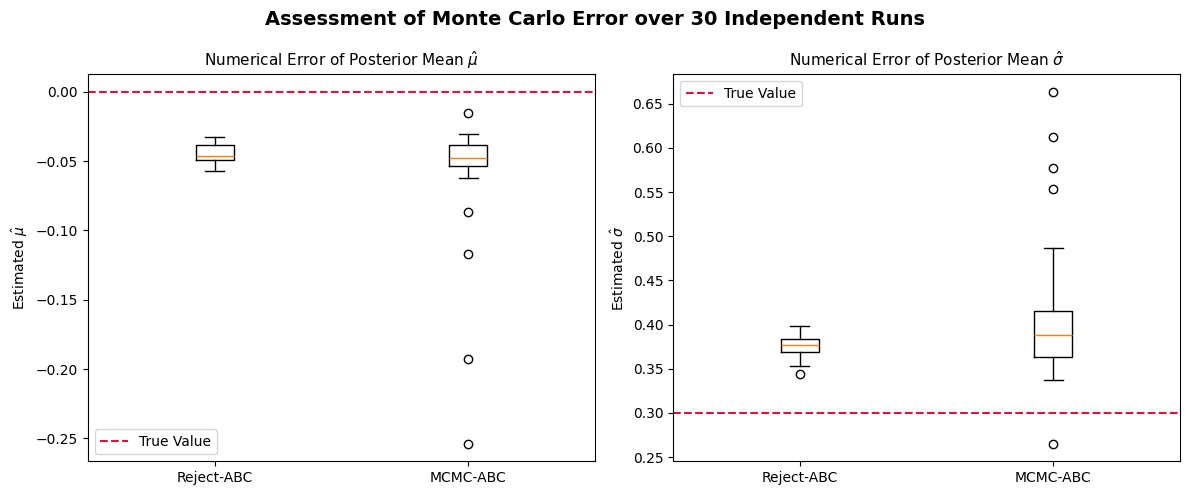

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Importation des modules du projet
from q1 import simulate_lognormal_sum, reject_abc
from ABCMCMC import ABCMCMC

# =============================================================================
# OBJECTIF : Évaluation de l'Erreur Standard de Monte Carlo (MCSE)
# Afin de mesurer la stabilité numérique des estimateurs (variance algorithmique),
# nous exécutons plusieurs itérations indépendantes des algorithmes Reject-ABC 
# et MCMC-ABC sur un jeu de données strictement identique.
# =============================================================================

# 1. Initialisation des paramètres de l'expérience
L_true, mu_true, sigma_true, n_obs = 10, 0.0, 0.3, 200
epsilon_val = 0.5
n_runs = 30  # Nombre d'exécutions indépendantes

# Listes de stockage pour les moyennes a posteriori estimées
mu_estimates_rej, sigma_estimates_rej = [], []
mu_estimates_mcmc, sigma_estimates_mcmc = [], []

print(f"Lancement de l'évaluation de l'erreur Monte Carlo sur {n_runs} exécutions...")

for i in range(n_runs):
    # Isolation de l'état aléatoire pour garantir l'indépendance de chaque exécution
    rng_run = np.random.default_rng(1000 + i)
    
    # 2. Fixation des observations empiriques (Y_obs)
    # Pour isoler l'erreur Monte Carlo de l'erreur d'échantillonnage des données, 
    # le jeu de données cible n'est généré qu'une seule fois.
    if i == 0:
        rng_data = np.random.default_rng(42)
        Y_obs_fixed = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
    
    # --- 3. Exécution du Rejection-ABC ---
    # Configuration avec un prior non-informatif standard (Well-calibrated)
    samples_rej, _ = reject_abc(
        Y_obs_fixed, L_true, s=1.0, t=1.0, epsilon=epsilon_val, 
        num_samples=50, rng=rng_run
    )
    
    if len(samples_rej) > 0:
        mu_estimates_rej.append(np.mean(samples_rej[:, 0]))
        sigma_estimates_rej.append(np.mean(samples_rej[:, 1])) # La colonne 1 contient sigma

    # --- 4. Exécution du MCMC-ABC ---
    # La taille de la chaîne est modérée pour maintenir un temps de calcul viable sur 30 runs
    chain_mcmc, _ = ABCMCMC(
        Y_obs_fixed, L_true, s=1.0, t=1.0, epsilon=epsilon_val, 
        step_mu=0.05, step_log_sigma2=0.05, num_samples=2000, rng=rng_run
    )
    
    # Traitement post-échantillonnage : exclusion du burn-in
    burnin = 400
    post_burnin_chain = chain_mcmc[burnin:]
    
    # Stockage de l'estimation de mu
    mu_estimates_mcmc.append(np.mean(post_burnin_chain[:, 0]))
    
    # Stockage de l'estimation de sigma
    # Note : La colonne 1 de MCMC-ABC contient log(sigma^2). On le transforme en sigma.
    sigma_mcmc_samples = np.sqrt(np.exp(post_burnin_chain[:, 1]))
    sigma_estimates_mcmc.append(np.mean(sigma_mcmc_samples))
    
    if (i + 1) % 5 == 0:
        print(f"  -> Exécution {i + 1}/{n_runs} terminée.")

# =============================================================================
# 5. Visualisation : Comparaison de la variance algorithmique (Box-plots)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique de la distribution des estimateurs pour mu
axes[0].boxplot([mu_estimates_rej, mu_estimates_mcmc], tick_labels=['Reject-ABC', 'MCMC-ABC'])
axes[0].axhline(mu_true, color='crimson', linestyle='--', label='True Value')
axes[0].set_title(r"Numerical Error of Posterior Mean $\hat{\mu}$", fontsize=11)
axes[0].set_ylabel(r"Estimated $\hat{\mu}$")
axes[0].legend()

# Graphique de la distribution des estimateurs pour sigma
axes[1].boxplot([sigma_estimates_rej, sigma_estimates_mcmc], tick_labels=['Reject-ABC', 'MCMC-ABC'])
axes[1].axhline(sigma_true, color='crimson', linestyle='--', label='True Value')
axes[1].set_title(r"Numerical Error of Posterior Mean $\hat{\sigma}$", fontsize=11)
axes[1].set_ylabel(r"Estimated $\hat{\sigma}$")
axes[1].legend()

plt.suptitle(f"Assessment of Monte Carlo Error over {n_runs} Independent Runs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("monte_carlo_error_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Version avec inverse gamma en prior 

In [3]:
import numpy as np
from q1_b import simulate_lognormal_sum, wasserstein_1d
from ABCMCMC_bis import ABCMCMC

L_true, mu_true, sigma_true, n_obs = 10, 0.0, 0.3, 200
epsilon_val    = 0.18
step_mu        = 0.02
step_log_sigma = 0.1
num_samples    = 50000

prior_configs = [
    {"a": 2.0,  "b": 1.0,  "kappa": 1.0,  "name": "Well-calibrated"},
    {"a": 1.0,  "b": 0.1,  "kappa": 10.0, "name": "Highly diffuse"},
]

rng_data = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}")

for i, config in enumerate(prior_configs):
    rng = np.random.default_rng(100 + i)   # seed isolé par config
    print(f"\n--- {config['name']} (a={config['a']}, b={config['b']}, kappa={config['kappa']}) ---")

    samples, acc_rate = ABCMCMC(
        Y_obs, L_true, config['a'], config['b'], config['kappa'],
        epsilon_val, step_mu, step_log_sigma,
        num_samples=num_samples, rng=rng
    )

    print(f"Acceptance Rate : {acc_rate:.4%}")
    print(f"mu estimé       : {np.mean(samples[:, 0]):.4f}  (vrai={mu_true})")
    print(f"log_sigma² est. : {np.mean(samples[:, 1]):.4f}  (vrai={2*np.log(sigma_true):.4f})")

Y_obs mean: 10.2882

--- Well-calibrated (a=2.0, b=1.0, kappa=1.0) ---
Acceptance Rate : 19.4960%
mu estimé       : -0.0337  (vrai=0.0)
log_sigma² est. : -2.0990  (vrai=-2.4079)

--- Highly diffuse (a=1.0, b=0.1, kappa=10.0) ---
Acceptance Rate : 39.2460%
mu estimé       : -0.0156  (vrai=0.0)
log_sigma² est. : -2.4372  (vrai=-2.4079)


In [12]:
from q1 import simulate_lognormal_sum


Y_obs mean: 10.2882

=== Lancement ABC-MCMC ===
  ⚠ Warm start: dist=0.3037 > ε=0.18 (mais on continue)
Taux d'acceptation : 19.79%

────────────────────────────────────────────────────────────
Paramètre        Moyenne      Std  IC 95% bas  IC 95% haut    ESS
────────────────────────────────────────────────────────────
mu               -0.0295   0.0131     -0.0544      -0.0039    489  (vrai = 0.000)
log_sigma2       -2.1300   0.1512     -2.4794      -1.8486    239  (vrai = -2.408)
────────────────────────────────────────────────────────────



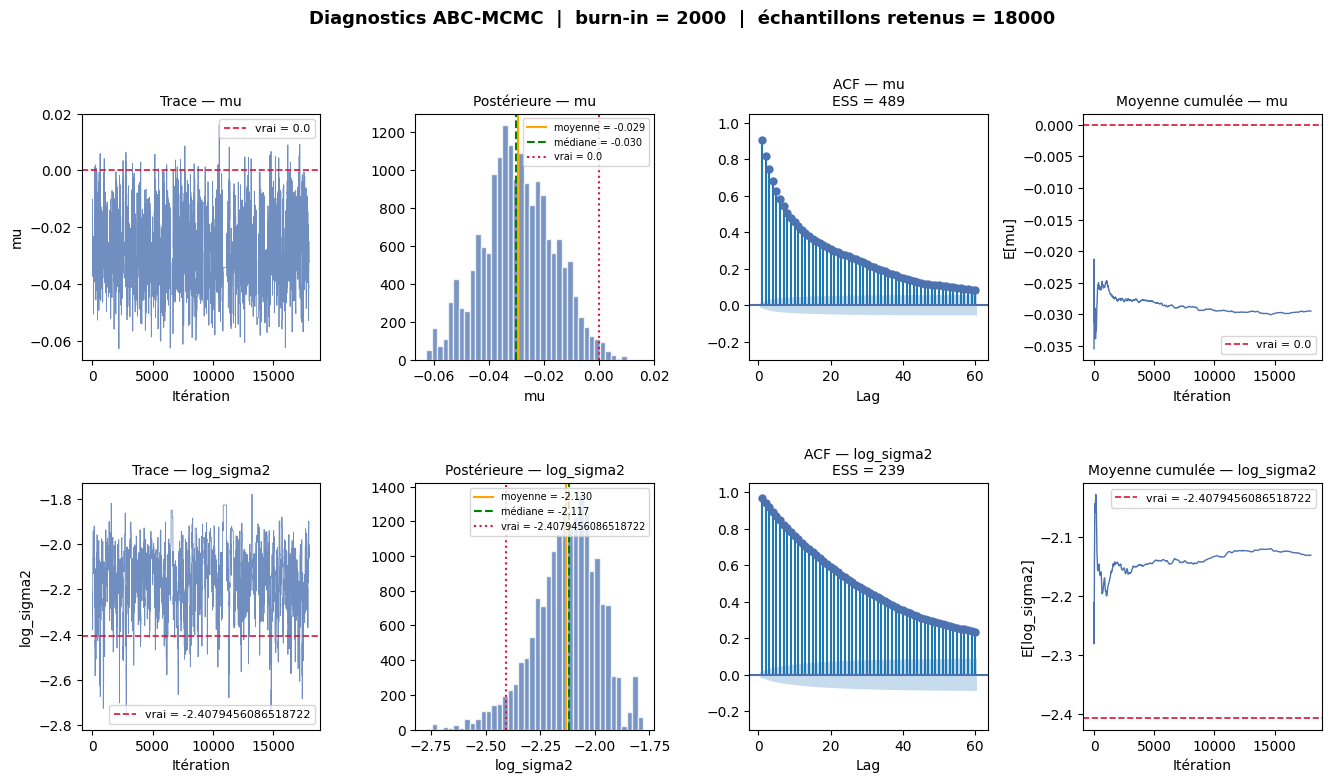

Figure sauvegardée : diagnostics_abcmcmc.png


In [3]:
import numpy as np
from q1 import simulate_lognormal_sum
from ABCMCMC_bis import ABCMCMC
from Figures import plot_diagnostics, print_summary

# Paramètres du modèle vrai
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200

# Générer les données observées
main_rng = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=main_rng)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}")

# Paramètres ABC-MCMC
epsilon_val = 0.18
step_mu = 0.02
step_log_sigma = 0.1

# Lancer ABC-MCMC
print("\n=== Lancement ABC-MCMC ===")
chain, acc_rate = ABCMCMC(
    Y_obs,           # 1er argument
    L_true,          # 2ème argument  
    2.0,             # a (3ème argument)
    1.0,             # b (4ème argument)
    1.0,             # kappa (5ème argument)
    epsilon_val,     # epsilon (6ème argument)
    step_mu,         # step_mu (7ème argument)
    step_log_sigma,  # step_log_sigma2 (8ème argument)
    num_samples=20000,  # Ceux-ci peuvent rester nommés
    rng=main_rng
)

print(f"Taux d'acceptation : {acc_rate:.2%}")

# Valeurs vraies pour comparaison
true_values = [mu_true, 2*np.log(sigma_true)]

# Afficher le résumé
print_summary(
    chain, 
    param_names=["mu", "log_sigma2"], 
    burnin=2000,
    true_values=true_values
)

# Afficher les diagnostics graphiques
plot_diagnostics(
    chain, 
    param_names=["mu", "log_sigma2"], 
    burnin=2000,
    true_values=true_values
)

In [14]:
import os
print("Fichiers dans le dossier courant :")
print(os.listdir('.'))

Fichiers dans le dossier courant :
['ABCMCMC.py', 'ABCMCMC_bis.py', 'diagnostics_abcmcmc.png', 'fig1_prior_impact.png', 'fig2_epsilon_impact.png', 'Figures', 'mcmc_traces.png', 'MonteCarlo.py', 'monte_carlo_error_boxplots.png', 'q1.py', 'q1_b.py', 'results.ipynb', 'results_bis.ipynb', '__pycache__']


In [1]:
import numpy as np
from q1 import simulate_lognormal_sum
from ABCMCMC_bis import ABCMCMC

# Paramètres du modèle vrai
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200

# Générer les données observées (avec un seed fixe)
rng_data = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}\n")

# Paramètres ABC-MCMC
epsilon_val = 0.18
step_mu = 0.02
step_log_sigma = 0.1
num_samples = 20000
burnin = 2000

# Prior
a, b, kappa = 2.0, 1.0, 1.0

# Lancer plusieurs chaînes avec des seeds différents
seeds = [42, 100, 200, 300, 400]
chains = []
acc_rates = []

print("=== Lancement de plusieurs chaînes ===\n")
for i, seed in enumerate(seeds):
    print(f"Chaîne {i+1} (seed={seed})... ", end="")
    rng = np.random.default_rng(seed)
    
    chain, acc_rate = ABCMCMC(
        Y_obs, L_true, 
        a, b, kappa,
        epsilon_val,
        step_mu,
        step_log_sigma,
        num_samples=num_samples,
        rng=rng
    )
    
    chains.append(chain)
    acc_rates.append(acc_rate)
    print(f"Taux d'acceptation : {acc_rate:.2%}")

print("\n" + "="*70)
print("RÉSUMÉ DES CHAÎNES (après burn-in)")
print("="*70)
print(f"{'Chaîne':<10} {'Acc. Rate':<12} {'µ moyen':<12} {'log(σ²) moyen':<15}")
print("-"*70)

for i, (chain, acc) in enumerate(zip(chains, acc_rates)):
    chain_post = chain[burnin:]
    mu_mean = np.mean(chain_post[:, 0])
    logsigma2_mean = np.mean(chain_post[:, 1])
    print(f"{i+1:<10} {acc:<12.2%} {mu_mean:<12.4f} {logsigma2_mean:<15.4f}")

print("-"*70)
print(f"{'Vraie valeur':<10} {'':<12} {mu_true:<12.4f} {2*np.log(sigma_true):<15.4f}")
print("="*70)

# Calculer les statistiques sur l'ensemble des chaînes
all_mu = [np.mean(chain[burnin:, 0]) for chain in chains]
all_logsigma2 = [np.mean(chain[burnin:, 1]) for chain in chains]

print(f"\n📊 VARIABILITÉ ENTRE CHAÎNES :")
print(f"   µ        : moyenne = {np.mean(all_mu):.4f}, écart-type = {np.std(all_mu):.4f}")
print(f"   log(σ²)  : moyenne = {np.mean(all_logsigma2):.4f}, écart-type = {np.std(all_logsigma2):.4f}")

Y_obs mean: 10.2882

=== Lancement de plusieurs chaînes ===

Chaîne 1 (seed=42)...   ⚠ Warm start: dist=0.3037 > ε=0.18 (mais on continue)
Taux d'acceptation : 19.79%
Chaîne 2 (seed=100)...   ⚠ Warm start échoué (best_dist=0.3638)
    → Utilisation valeur de secours: µ=0, log(σ²)=-2
    → Distance avec valeur de secours: 0.3603
Taux d'acceptation : 21.61%
Chaîne 3 (seed=200)...   ⚠ Warm start échoué (best_dist=0.4155)
    → Utilisation valeur de secours: µ=0, log(σ²)=-2
    → Distance avec valeur de secours: 0.4985
Taux d'acceptation : 21.52%
Chaîne 4 (seed=300)...   ⚠ Warm start: dist=0.3442 > ε=0.18 (mais on continue)
Taux d'acceptation : 16.56%
Chaîne 5 (seed=400)...   ✓ Warm start valide: dist=0.1578 <= ε=0.18
Taux d'acceptation : 19.77%

RÉSUMÉ DES CHAÎNES (après burn-in)
Chaîne     Acc. Rate    µ moyen      log(σ²) moyen  
----------------------------------------------------------------------
1          19.79%       -0.0295      -2.1300        
2          21.61%       -0.0292    

In [2]:
import numpy as np

# Après burn-in
chains_post = [chain[burnin:] for chain in chains]

def compute_rhat(chains_list, param_idx):
    """
    Calcule le R-hat pour un paramètre donné.
    R-hat < 1.01 : excellent
    R-hat < 1.05 : bon
    R-hat > 1.1  : problème
    """
    m = len(chains_list)  # nombre de chaînes
    n = len(chains_list[0])  # longueur de chaque chaîne
    
    # Moyennes par chaîne
    chain_means = np.array([np.mean(chain[:, param_idx]) for chain in chains_list])
    
    # Variance intra-chaîne (moyenne des variances)
    W = np.mean([np.var(chain[:, param_idx], ddof=1) for chain in chains_list])
    
    # Variance inter-chaîne
    B = n * np.var(chain_means, ddof=1)
    
    # Variance totale estimée
    var_hat = ((n - 1) / n) * W + (1 / n) * B
    
    # R-hat
    rhat = np.sqrt(var_hat / W)
    
    return rhat

# Calculer R-hat
burnin = 2000
chains_post = [chain[burnin:] for chain in chains]

rhat_mu = compute_rhat(chains_post, 0)
rhat_logsigma2 = compute_rhat(chains_post, 1)

print(f"\n🎯 R-hat (Gelman-Rubin diagnostic):")
print(f"   µ        : {rhat_mu:.4f}  {'✅ Excellent!' if rhat_mu < 1.01 else '✅ Bon' if rhat_mu < 1.05 else '⚠️ Problème'}")
print(f"   log(σ²)  : {rhat_logsigma2:.4f}  {'✅ Excellent!' if rhat_logsigma2 < 1.01 else '✅ Bon' if rhat_logsigma2 < 1.05 else '⚠️ Problème'}")


🎯 R-hat (Gelman-Rubin diagnostic):
   µ        : 1.0106  ✅ Bon
   log(σ²)  : 1.0095  ✅ Excellent!


Y_obs mean: 10.2882

COMPARAISON SYSTÉMATIQUE : ESS et Autocorrélation

📌 ε=0.15, steps=Très petit (µ=0.01, log(σ²)=0.05)
  ⚠ Warm start: dist=0.1771 > ε=0.15 (mais on continue)
   Acc: 28.8% | ESS(µ):  268 | ESS(log σ²):  161
   Biais(µ): -0.0259 | Biais(log σ²): +0.2095

📌 ε=0.15, steps=Petit (baseline) (µ=0.02, log(σ²)=0.1)
  ⚠ Warm start échoué (best_dist=0.4583)
    → Utilisation valeur de secours: µ=0, log(σ²)=-2
    → Distance avec valeur de secours: 0.4277
   Acc: 17.7% | ESS(µ):  388 | ESS(log σ²):  199
   Biais(µ): -0.0256 | Biais(log σ²): +0.2126

📌 ε=0.15, steps=Moyen (µ=0.05, log(σ²)=0.2)
  ⚠ Warm start échoué (best_dist=0.4065)
    → Utilisation valeur de secours: µ=0, log(σ²)=-2
    → Distance avec valeur de secours: 0.4294
   Acc:  5.4% | ESS(µ):  180 | ESS(log σ²):  123
   Biais(µ): -0.0271 | Biais(log σ²): +0.2348

📌 ε=0.15, steps=Grand (µ=0.1, log(σ²)=0.3)
  ⚠ Warm start: dist=0.1832 > ε=0.15 (mais on continue)
   Acc:  2.3% | ESS(µ):   85 | ESS(log σ²):   54
   Biai

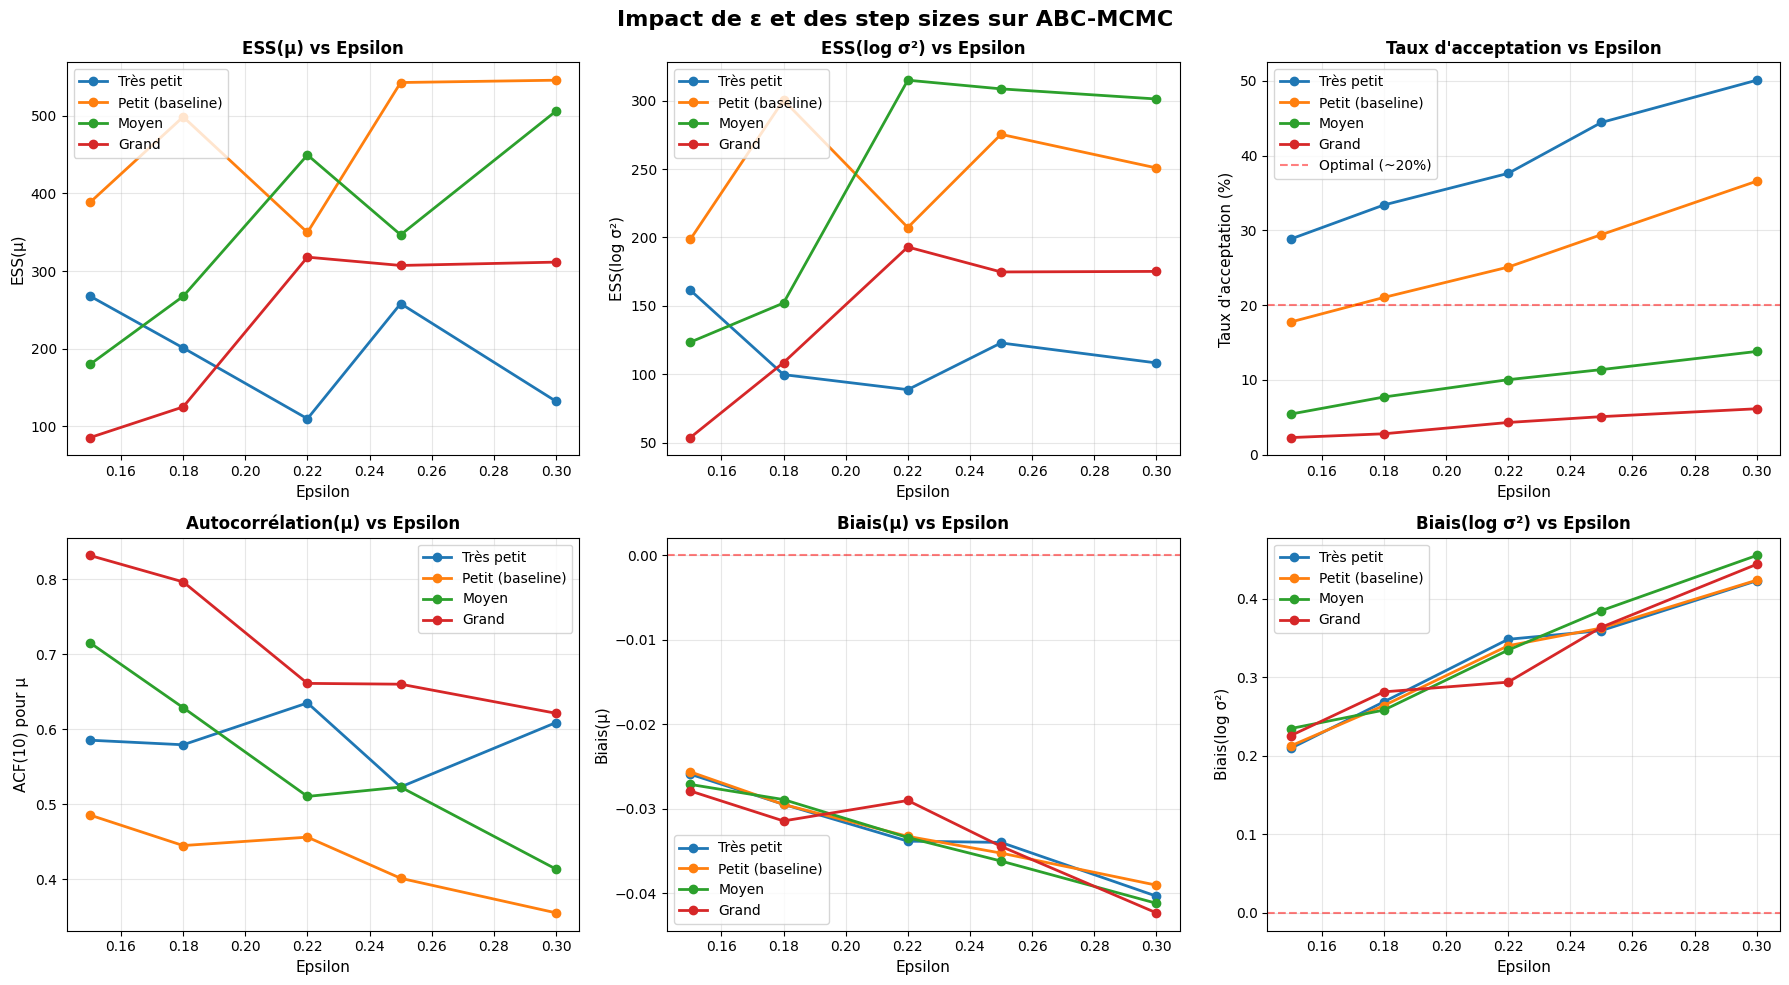


✅ Figure sauvegardée : abc_mcmc_sensitivity_analysis.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from q1 import simulate_lognormal_sum
from ABCMCMC_bis import ABCMCMC
from Figures import effective_sample_size

# Paramètres du modèle vrai
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200

# Générer les données observées (seed fixe pour comparaison équitable)
rng_data = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}\n")

# === GRILLE DE PARAMÈTRES À TESTER ===

# Variation de epsilon
epsilons = [0.15, 0.18, 0.22, 0.25, 0.30]

# Variation des step sizes
step_configs = [
    {"step_mu": 0.01, "step_log_sigma": 0.05, "name": "Très petit"},
    {"step_mu": 0.02, "step_log_sigma": 0.10, "name": "Petit (baseline)"},
    {"step_mu": 0.05, "step_log_sigma": 0.20, "name": "Moyen"},
    {"step_mu": 0.10, "step_log_sigma": 0.30, "name": "Grand"},
]

# Paramètres MCMC
num_samples = 20000
burnin = 2000
a, b, kappa = 2.0, 1.0, 1.0

# === BOUCLE DE TESTS ===

results = []

print("="*80)
print("COMPARAISON SYSTÉMATIQUE : ESS et Autocorrélation")
print("="*80)

for eps in epsilons:
    for step_config in step_configs:
        step_mu = step_config["step_mu"]
        step_log_sigma = step_config["step_log_sigma"]
        name = step_config["name"]
        
        print(f"\n📌 ε={eps:.2f}, steps={name} (µ={step_mu}, log(σ²)={step_log_sigma})")
        
        # Lancer ABC-MCMC avec un seed unique
        rng = np.random.default_rng(int(eps*1000 + step_mu*10000))
        
        chain, acc_rate = ABCMCMC(
            Y_obs, L_true, a, b, kappa,
            epsilon=eps,
            step_mu=step_mu,
            step_log_sigma2=step_log_sigma,
            num_samples=num_samples,
            rng=rng
        )
        
        # Calculs post burn-in
        chain_post = chain[burnin:]
        
        # ESS
        ess_mu = effective_sample_size(chain_post[:, 0])
        ess_logsigma2 = effective_sample_size(chain_post[:, 1])
        
        # Autocorrélation au lag 10
        from statsmodels.tsa.stattools import acf
        acf_mu = acf(chain_post[:, 0], nlags=10, fft=True)[10]
        acf_logsigma2 = acf(chain_post[:, 1], nlags=10, fft=True)[10]
        
        # Estimations
        mu_mean = np.mean(chain_post[:, 0])
        logsigma2_mean = np.mean(chain_post[:, 1])
        
        # Biais
        bias_mu = mu_mean - mu_true
        bias_logsigma2 = logsigma2_mean - 2*np.log(sigma_true)
        
        print(f"   Acc: {acc_rate:5.1%} | ESS(µ): {ess_mu:4.0f} | ESS(log σ²): {ess_logsigma2:4.0f}")
        print(f"   Biais(µ): {bias_mu:+.4f} | Biais(log σ²): {bias_logsigma2:+.4f}")
        
        # Stocker les résultats
        results.append({
            'epsilon': eps,
            'step_name': name,
            'step_mu': step_mu,
            'step_log_sigma': step_log_sigma,
            'acc_rate': acc_rate,
            'ess_mu': ess_mu,
            'ess_logsigma2': ess_logsigma2,
            'acf10_mu': acf_mu,
            'acf10_logsigma2': acf_logsigma2,
            'bias_mu': bias_mu,
            'bias_logsigma2': bias_logsigma2,
            'mu_mean': mu_mean,
            'logsigma2_mean': logsigma2_mean
        })

# === CRÉATION DU DATAFRAME ===

df = pd.DataFrame(results)
print("\n" + "="*80)
print("TABLEAU RÉCAPITULATIF")
print("="*80)
print(df.to_string(index=False))

# === VISUALISATIONS ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Impact de ε et des step sizes sur ABC-MCMC", fontsize=16, fontweight='bold')

# 1. ESS(µ) en fonction de epsilon (groupé par step size)
ax = axes[0, 0]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['ess_mu'], marker='o', label=step_name, linewidth=2)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('ESS(µ)', fontsize=11)
ax.set_title('ESS(µ) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. ESS(log σ²) en fonction de epsilon
ax = axes[0, 1]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['ess_logsigma2'], marker='o', label=step_name, linewidth=2)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('ESS(log σ²)', fontsize=11)
ax.set_title('ESS(log σ²) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Taux d'acceptation vs epsilon
ax = axes[0, 2]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['acc_rate']*100, marker='o', label=step_name, linewidth=2)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('Taux d\'acceptation (%)', fontsize=11)
ax.set_title('Taux d\'acceptation vs Epsilon', fontsize=12, fontweight='bold')
ax.axhline(20, color='red', linestyle='--', alpha=0.5, label='Optimal (~20%)')
ax.legend()
ax.grid(alpha=0.3)

# 4. Autocorrélation(µ) au lag 10
ax = axes[1, 0]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['acf10_mu'], marker='o', label=step_name, linewidth=2)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('ACF(10) pour µ', fontsize=11)
ax.set_title('Autocorrélation(µ) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 5. Biais(µ)
ax = axes[1, 1]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['bias_mu'], marker='o', label=step_name, linewidth=2)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('Biais(µ)', fontsize=11)
ax.set_title('Biais(µ) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 6. Biais(log σ²)
ax = axes[1, 2]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['bias_logsigma2'], marker='o', label=step_name, linewidth=2)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('Biais(log σ²)', fontsize=11)
ax.set_title('Biais(log σ²) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('abc_mcmc_sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figure sauvegardée : abc_mcmc_sensitivity_analysis.png")